# Image Processing

# Pillow

# Importing Image

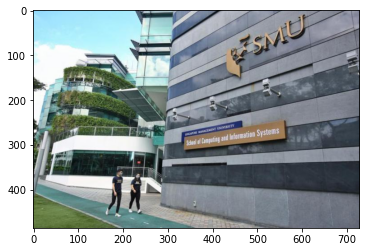

In [177]:
from PIL import Image
import matplotlib.pyplot as plt

scis1 = Image.open('../data/scis1.jpeg')
plt.imshow(scis1)
plt.show()

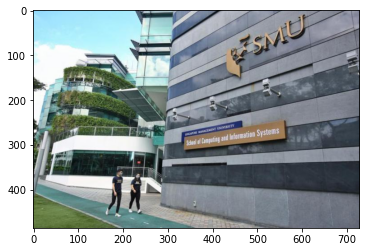

## Common Operations

Original size: (729, 486)
New size: (360, 240)


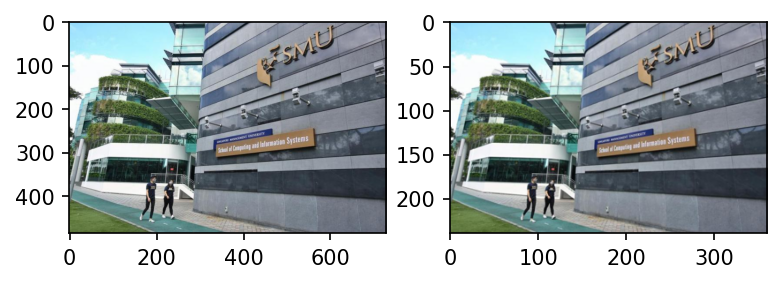

In [178]:
# Resize
from PIL import Image
import matplotlib.pyplot as plt

scis1 = Image.open('../data/scis1.jpeg')

scis1_sm = scis1.resize((360, 240))

print(f"Original size: {scis1.size}")
print(f"New size: {scis1_sm.size}")
# Original size: (729, 486)
# New size: (360, 240)

fig, axs = plt.subplots(1, 2)
axs[0].imshow(scis1)
axs[1].imshow(scis1_sm)


fig.set_dpi(150)
plt.show()

## Gray Scale Image

Shape: (486, 729), Data Type: uint8


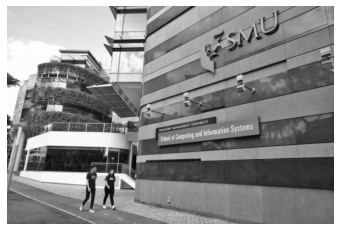

In [180]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

scis1 = Image.open('../data/scis1.jpeg')

gray = np.array(scis1.convert('L'))
print(f'Shape: {gray.shape}, Data Type: {gray.dtype}')
# Shape: (486, 729), Data Type: uint8

plt.imshow(gray)
plt.axis('off')
plt.gray()
plt.show()

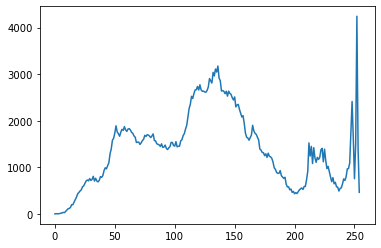

In [181]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

scis1 = Image.open('../data/scis1.jpeg')

gray = np.array(scis1.convert('L'))

histogram, bins = np.histogram(gray, bins=255, range=(0, 255))
plt.plot(bins[:-1], histogram)
plt.show()

## RGB Image and Histogram

Shape: (486, 729, 3), Data Type: uint8


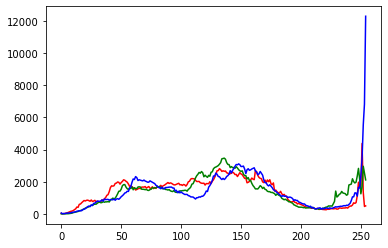

In [182]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

scis1 = Image.open('../data/scis1.jpeg')
a = np.array(scis1)
print(f'Shape: {a.shape}, Data Type: {a.dtype}')

hist_r, bins = np.histogram(a[:,:,0], bins=255, range=(0, 255))
hist_g, bins = np.histogram(a[:,:,1], bins=255, range=(0, 255))
hist_b, bins = np.histogram(a[:,:,2], bins=255, range=(0, 255))
plt.plot(bins[:-1], hist_r, color='r')
plt.plot(bins[:-1], hist_g, color='g')
plt.plot(bins[:-1], hist_b, color='b')
plt.show()

## Filters

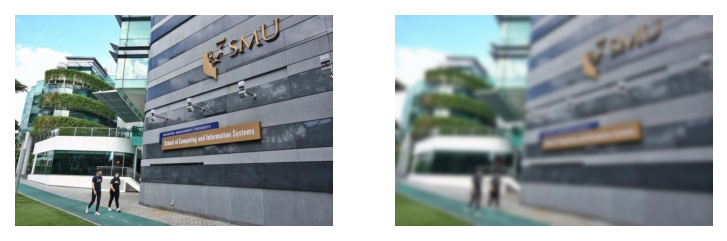

In [172]:
# Gaussian Filter
from scipy.ndimage import gaussian_filter

a1 = np.array(scis1)
a2 = gaussian_filter(a1, sigma=(5, 5, 0))

fig, axs = plt.subplots(1, 2)
fig.set_dpi(150)
axs[0].imshow(a1)
axs[1].imshow(a2)

axs[0].axis('off')
axs[1].axis('off')

plt.show()

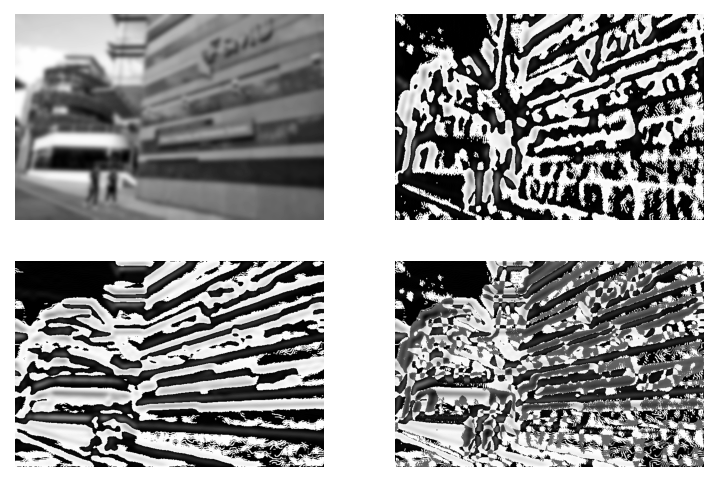

In [173]:
# Sobel filter
# https://scipy-lectures.org/advanced/image_processing/auto_examples/plot_find_edges.html
from scipy.ndimage import sobel, laplace

gray = np.array(scis1.convert('L'))
gray = gaussian_filter(gray, sigma=(5,5))

fig, axs = plt.subplots(2, 2)
fig.set_dpi(150)
plt.gray()


sl = laplace(gray)
sx = sobel(gray, axis=1)
sy = sobel(gray, axis=0)
sob = np.hypot(sx, sy).astype('uint8')

axs[0, 0].imshow(gray)
axs[0, 1].imshow(sx)
axs[1, 0].imshow(sy)
axs[1, 1].imshow(sob)

axs[0, 0].axis('off')
axs[0, 1].axis('off')
axs[1, 0].axis('off')
axs[1, 1].axis('off')

plt.show()